# Using synthetic data to find heterogeneity

On COMPAS, when a method reports a coefficient flip, we dont know if it's real or an artifact, so build synthetic datasets where we do know the answer, and run every method on those first.

Three datasets:

| | what is in it | what a method should say |
|---|---|---|
| Synthetic A | everyone follows the same rule | "no flip" |
| Synthetic B | same rule, except under-25s, where priors works backwards | "priors flips, in the young" |
| Synthetic C | same, but the flipped group is people with a long jail stay | "priors flips, somewhere" |

- A: There is no flip. Any method that reports one is wrong, guaranteed.
- B: There is a flip, and it sits inside a demographic group, so a method that
  splits by race and age has a cell that contains it.
- C: There is a flip, but "long jail stay" is not a demographic group. It
  cuts across race and age. So demographic methods have no cell that contains it. C asks whether a
  method can find structure it was not already told where to look for.

The planted flip is magnitude-controlled: in both B and C, the generating rule's slope on the
group's own standardized priors is forced to exactly -beta (the real global priors effect, sign
reversed). Same magnitude, same group size, the only thing that differs between B and C is where
the flip lives. (An earlier version subtracted 2 x beta on the globally standardized scale, which
quietly made B's flip ~10x weaker than C's, because under-25s have far less priors variance
(std ~2) than long-stayers (std ~6). Every power comparison was confounded by that.)

Everything in this notebook is a logistic regression. That is deliberate: the whole
question is about coefficients flipping sign, and only a linear model has coefficients.

## Part 0: setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.cluster import KMeans
from sklearn.metrics import log_loss, roc_auc_score
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
SEED = 42

In [2]:
df = pd.read_csv("clean-compas-scores-two-year.csv")
df["sex_male"] = (df["sex"] == "Male").astype(int)
df["charge_felony"] = (df["c_charge_degree"] == "F").astype(int)
df["race_age"] = df["race_for_model"] + " / " + df["age_cat"]

FEATURES = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count",
            "len_of_stay", "days_b_screening_arrest", "sex_male", "charge_felony"]

X = df[FEATURES]
Xv = X.values
Xs = StandardScaler().fit_transform(X)      # standardized, so coefficients are comparable
groups = df["race_age"]                     # the 9 demographic cells every method gets handed
y_real = df["two_year_recid"].values

J_PRIORS = FEATURES.index("priors_count")

print("people:", len(df), " features:", len(FEATURES), " demographic cells:", groups.nunique())
print("real recidivism rate:", round(y_real.mean(), 3))

people: 6172  features: 9  demographic cells: 9
real recidivism rate: 0.455


## Part 1: Making the synthetic labels

So the rule that generates the labels has to be flexible and realistic, so we use XGBoost

In [4]:
def make_xgb():
    return XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                         eval_metric="logloss", random_state=SEED, verbosity=0)

# how well does each candidate rule fit real COMPAS?
print("which rule should generate the synthetic labels?")
print("=" * 62)
for name, (mdl, D) in {
    "logistic (straight lines)": (make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)), Xs),
    "XGBoost (can bend)":        (make_xgb(), Xv),
}.items():
    p = cross_val_predict(mdl, D, y_real, cv=5, method="predict_proba")[:, 1]
    print(f"  {name:28s} log loss {log_loss(y_real, p):.4f}   AUC {roc_auc_score(y_real, p):.4f}")

print()
print("XGBoost fits real COMPAS better, so it makes more realistic fake data.")

which rule should generate the synthetic labels?
  logistic (straight lines)    log loss 0.6078   AUC 0.7315
  XGBoost (can bend)           log loss 0.5921   AUC 0.7450

XGBoost fits real COMPAS better, so it makes more realistic fake data.


In [5]:
# the generating rule: each person's probability of reoffending, from XGBoost, out of fold
p_gen = cross_val_predict(make_xgb(), Xv, y_real, cv=5, method="predict_proba")[:, 1]
p_gen = np.clip(p_gen, 1e-6, 1 - 1e-6)
logit_gen = np.log(p_gen / (1 - p_gen))     # the rule, on the log-odds scale,

# how strong is the priors effect in real COMPAS? need this to know how big a flip to plant
BETA_PRIORS = LogisticRegression(max_iter=3000).fit(Xs, y_real).coef_[0][J_PRIORS]
print("priors coefficient in real COMPAS:", round(float(BETA_PRIORS), 3), "(positive: more priors, more risk)")

priors coefficient in real COMPAS: 0.754 (positive: more priors, more risk)


In [6]:
# the two groups I will flip. same size by construction, the planted magnitude is equalized
# inside make_synthetic, so the only difference between B and C really
# is where the flip lives

GROUP_B = (df["age_cat"] == "Less than 25").values                       # a demographic group
GROUP_C = (df["len_of_stay"] >= df["len_of_stay"].quantile(0.80)).values  # not a demographic group

print(f"synthetic B flips priors for: age under 25       -> {GROUP_B.sum():4d} people ({GROUP_B.mean():.1%})")
print(f"synthetic C flips priors for: longest 20% of stays -> {GROUP_C.sum():4d} people ({GROUP_C.mean():.1%})")
print()
print("does group C sit inside any demographic cell? (if it did, demographic methods could find it")
print("by accident and the test would be rigged)")
print()
print(pd.crosstab(groups, GROUP_C, normalize="index")[True].round(2).to_string())
print()
print("every cell is about 20% inside group C. none isolates it. so group C genuinely cuts across")
print("the demographic partition, which is exactly what makes it a fair test.")

synthetic B flips priors for: age under 25       -> 1347 people (21.8%)
synthetic C flips priors for: longest 20% of stays -> 1267 people (20.5%)

does group C sit inside any demographic cell? (if it did, demographic methods could find it
by accident and the test would be rigged)

race_age
African-American / 25 - 45            0.22
African-American / Greater than 45    0.25
African-American / Less than 25       0.21
Caucasian / 25 - 45                   0.20
Caucasian / Greater than 45           0.21
Caucasian / Less than 25              0.17
Other / 25 - 45                       0.15
Other / Greater than 45               0.17
Other / Less than 25                  0.18

every cell is about 20% inside group C. none isolates it. so group C genuinely cuts across
the demographic partition, which is exactly what makes it a fair test.


In [7]:
PRIORS_RAW = df["priors_count"].values.astype(float)

def plant_flip(rule, mask, target):
    """
    force the generating rule's slope on the group's OWN standardized priors to `target`,
    for the people in `mask`, leaving everyone else untouched.

    why not just subtract 2*beta*Xs_priors? because Xs is standardized on the whole dataset.
    under-25s have priors std ~2 vs ~5 elsewhere, so on the global scale that subtraction barely
    moves them and the planted flip came out ~10x weaker in B than in C (measured inside-group
    coefficients were -0.09 vs -1.07). planting on the group's own scale makes the magnitude
    identical by construction.
    """
    z = np.zeros(len(rule))
    z[mask] = (PRIORS_RAW[mask] - PRIORS_RAW[mask].mean()) / PRIORS_RAW[mask].std()
    b_local = np.polyfit(z[mask], rule[mask], 1)[0]   # the rule's current local priors slope
    return rule - (b_local - target) * z              # new local slope = target, exactly


def make_synthetic(which, rng):
    """
    'A' : everyone follows the same rule. NO flip exists.
    'B' : same rule, but priors works backwards for the under-25s.
    'C' : same rule, but priors works backwards for the longest-staying 20%.

    in B and C the generating rule's within-group standardized priors slope is exactly
    -BETA_PRIORS, so the two planted flips are the same strength.
    """
    rule = logit_gen.copy()
    if which == "B":
        rule = plant_flip(rule, GROUP_B, -BETA_PRIORS)
    elif which == "C":
        rule = plant_flip(rule, GROUP_C, -BETA_PRIORS)
    elif which != "A":
        raise ValueError(which)
    return rng.binomial(1, 1 / (1 + np.exp(-rule)))     # flip the weighted coin


SYNTH = ["A", "B", "C"]

In [8]:
rng = np.random.default_rng(SEED)

print("does the synthetic data look like COMPAS?")
print("=" * 62)
print(f"{'dataset':>14} {'recid rate':>12} {'priors-recid corr':>19}")
print("-" * 62)
print(f"{'real COMPAS':>14} {y_real.mean():12.3f} {np.corrcoef(df.priors_count, y_real)[0,1]:19.3f}")
for s in SYNTH:
    ys = make_synthetic(s, rng)
    print(f"{'synthetic ' + s:>14} {ys.mean():12.3f} {np.corrcoef(df.priors_count, ys)[0,1]:19.3f}")

does the synthetic data look like COMPAS?
       dataset   recid rate   priors-recid corr
--------------------------------------------------------------
   real COMPAS        0.455               0.291
   synthetic A        0.451               0.297
   synthetic B        0.455               0.250
   synthetic C        0.455               0.150


In [9]:
print("is the flip there?")
print("=" * 70)
rng = np.random.default_rng(SEED)

for s, grp, label in [("A", GROUP_B, "under 25 (nothing was planted)"),
                      ("B", GROUP_B, "under 25"),
                      ("C", GROUP_C, "longest 20% of stays")]:
    ys = make_synthetic(s, rng)
    inside  = LogisticRegression(max_iter=3000).fit(
        StandardScaler().fit_transform(X[grp]), ys[grp]).coef_[0][J_PRIORS]
    outside = LogisticRegression(max_iter=3000).fit(
        StandardScaler().fit_transform(X[~grp]), ys[~grp]).coef_[0][J_PRIORS]
    verdict = "flip is there" if inside * outside < 0 else "no flip (correct for A)"
    print(f"synthetic {s}  group = {label}")
    print(f"    priors coefficient inside : {inside:+.3f}")
    print(f"    priors coefficient outside: {outside:+.3f}   -> {verdict}")
    print()

is the flip there?
synthetic A  group = under 25 (nothing was planted)
    priors coefficient inside : +0.712
    priors coefficient outside: +0.852   -> no flip (correct for A)

synthetic B  group = under 25
    priors coefficient inside : -0.539
    priors coefficient outside: +0.868   -> flip is there

synthetic C  group = longest 20% of stays
    priors coefficient inside : -0.631
    priors coefficient outside: +0.670   -> flip is there



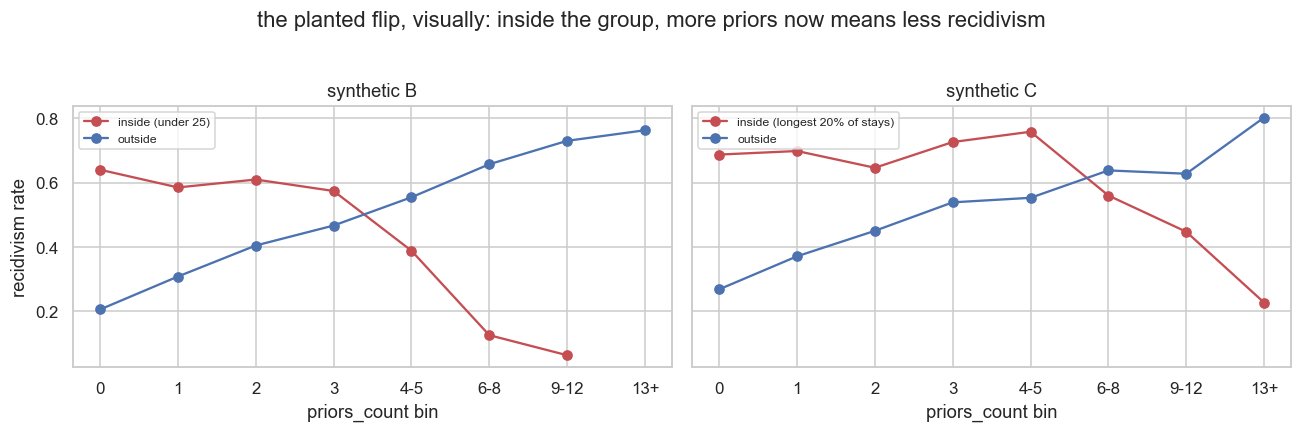

In [10]:
# see the planted flip: recidivism vs priors, inside vs outside the flip group.
# both panels should show the red (inside) curve sloping down while blue slopes up

rng = np.random.default_rng(SEED)
pbins = [-0.1, 0, 1, 2, 3, 5, 8, 12, 100]
plabels = ["0", "1", "2", "3", "4-5", "6-8", "9-12", "13+"]
pb = pd.cut(df["priors_count"], bins=pbins, labels=plabels)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, s, grp, lbl in [(axes[0], "B", GROUP_B, "under 25"),
                        (axes[1], "C", GROUP_C, "longest 20% of stays")]:
    ys = pd.Series(make_synthetic(s, rng))
    for mask, name, color in [(grp, f"inside ({lbl})", "#C44E52"),
                              (~grp, "outside", "#4C72B0")]:
        r = ys[mask].groupby(pb[mask], observed=True).mean()
        n = ys[mask].groupby(pb[mask], observed=True).size()
        r = r[n >= 15]
        ax.plot(r.index.astype(str), r.values, "o-", color=color, label=name)
    ax.set_title(f"synthetic {s}")
    ax.set_xlabel("priors_count bin")
    ax.legend(fontsize=8)
axes[0].set_ylabel("recidivism rate")
plt.suptitle("the planted flip, visually: inside the group, more priors now means less recidivism", y=1.03)
plt.tight_layout()
plt.show()

## Part 2: Is there a flip?

| method | what it does |
|---|---|
| M1 naive | fit a logistic regression in each of the 9 demographic cells, flag any feature whose coefficient changes sign |
| M2 corrected | same cells, but a flip only counts if it survives a bootstrap, the feature actually varies in the group, and the coefficient is not tiny |
| M3 cluster | no demographics: cluster people by how a zoo of models predicts them (out-of-fold, see below), then fit a model per cluster and flag naive flips |
| M3b cluster + gauntlet | same clusters, but a flip must pass the M2 checks |
| M4 gain | ignore coefficients entirely. do per-group models simply predict held-out data better than one global model? |

M3 is the "discover hidden subpopulations" idea, the only method with any chance of finding
synthetic C.

Two notes on M3. First, the zoo predictions must be out-of-fold: an earlier version predicted
in-sample, and a depth-8 random forest partially memorizes the labels, so the behaviour profiles
encoded y and the clustering was conditioning on the outcome so spurious flips guaranteed. Second,
even with OOF profiles, clustering on predicted risk still selects on a function of the features,
which can distort within-cluster coefficients without any true heterogeneity. That is why M3b holds
cluster flips to the same evidentiary standard as demographic ones. The naive/corrected split is the
same experiment run twice: once on a handed partition (M1/M2), once on a discovered one (M3/M3b).

In [11]:
FLIP_THRESHOLD = 0.1     # ignore coefficients this close to zero

def naive_flips(y, labels, min_n=100):
    "one logistic regression per group; flag any feature with a clearly + and a clearly - coefficient"
    t = {}
    for g in pd.unique(labels):
        m = (labels == g)
        if m.sum() < min_n or len(np.unique(y[m])) < 2:
            continue
        t[g] = pd.Series(LogisticRegression(C=1.0, max_iter=3000).fit(
            StandardScaler().fit_transform(Xv[m]), y[m]).coef_[0], index=FEATURES)
    t = pd.DataFrame(t)
    return [f for f in FEATURES
            if (t.loc[f] > FLIP_THRESHOLD).any() and (t.loc[f] < -FLIP_THRESHOLD).any()]


def M1_naive(y, rng):
    return naive_flips(y, groups.values)

In [13]:
def gauntlet_flips(y, labels, rng, n_boot=100, min_support=20, min_mag=0.10,
                   hi=0.95, lo=0.05, min_n=100):
    # a flip only counts if, for both groups involved:
    #   1. support: the feature actually varies in that group (at least 20 nonzero values).
    #      without this, a feature that is constant in a group gets a coefficient of exactly 0
    #      and a naive sign test reads that as confidently negative
    #   2. stability: the sign holds up in at least 95% of bootstrap resamples
    #   3. size: the point-estimate coefficient is not tiny
    # works on any partition: demographic cells (M2) or discovered clusters (M3b).
    point, signp, support = {}, {}, {}

    for g in pd.unique(labels):
        idx = np.where(labels == g)[0]
        if len(idx) < min_n or len(np.unique(y[idx])) < 2:
            continue
        Xg, yg = Xv[idx], y[idx]
        point[g] = pd.Series(LogisticRegression(C=1.0, max_iter=3000).fit(
            StandardScaler().fit_transform(Xg), yg).coef_[0], index=FEATURES)
        support[g] = pd.Series((Xg != 0).sum(axis=0), index=FEATURES)

        pos, ok = np.zeros(len(FEATURES)), 0
        for _ in range(n_boot):
            b = rng.integers(0, len(idx), len(idx))
            if len(np.unique(yg[b])) < 2:
                continue
            pos += LogisticRegression(C=1.0, max_iter=3000).fit(
                StandardScaler().fit_transform(Xg[b]), yg[b]).coef_[0] > 0
            ok += 1
        signp[g] = pd.Series(pos / max(ok, 1), index=FEATURES)

    point, signp, support = pd.DataFrame(point), pd.DataFrame(signp), pd.DataFrame(support)

    flips = []
    for f in FEATURES:
        ok_g = [g for g in point.columns if support.loc[f, g] >= min_support]
        if len(ok_g) < 2:
            continue
        pos_g = [g for g in ok_g if signp.loc[f, g] >= hi and point.loc[f, g] >= min_mag]
        neg_g = [g for g in ok_g if signp.loc[f, g] <= lo and point.loc[f, g] <= -min_mag]
        if pos_g and neg_g:
            flips.append(f)
    return flips


def M2_corrected(y, rng):
    return gauntlet_flips(y, groups.values, rng)

In [14]:
_cluster_cache = {}   # zoo is expensive, M3 and M3b share one clustering per dataset

def cluster_labels_oof(y, K=4):
    """cluster people by out-of-fold prediction profiles.

    the OOF part is not optional. in-sample profiles are a leak: a depth-8 forest partially
    memorizes y, the profile then encodes the label, and clustering on it conditions on the
    outcome -- per-cluster flips appear out of nothing"""
    key = y.tobytes()
    if key in _cluster_cache:
        return _cluster_cache[key]
    zoo = [cross_val_predict(LogisticRegression(C=c, max_iter=2000), Xs, y,
                             cv=5, method="predict_proba")[:, 1] for c in [0.01, 1.0]]
    zoo += [cross_val_predict(RandomForestClassifier(60, max_depth=d, random_state=SEED, n_jobs=-1),
                              Xv, y, cv=5, method="predict_proba")[:, 1] for d in [3, 8]]
    profiles = StandardScaler().fit_transform(np.column_stack(zoo))
    lab = KMeans(K, random_state=SEED, n_init=5).fit_predict(profiles)
    _cluster_cache[key] = lab
    return lab


def M3_cluster(y, rng, K=4):
    return naive_flips(y, cluster_labels_oof(y, K))


def M3b_gauntlet(y, rng, K=4):
    # even with OOF profiles, clusters are functions of predicted risk, i.e. of the features,
    # so within-cluster coefficients live under selection. hold them to the M2 standard.
    return gauntlet_flips(y, cluster_labels_oof(y, K), rng)

In [15]:
def M4_gain(y, min_n=100, seed=SEED):
    # do 9 per-group models beat 1 global model on held out data?
    # positive = per-group models are better.
    pg, pl = np.zeros(len(y)), np.zeros(len(y))
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=seed).split(Xs, y):
        gm = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=3000)).fit(Xs[tr], y[tr])
        pg[te] = gm.predict_proba(Xs[te])[:, 1]
        gtr, gte = groups.iloc[tr], groups.iloc[te]
        for g in pd.unique(gte):
            tem, trm = (gte == g).values, (gtr == g).values
            if trm.sum() < min_n or len(np.unique(y[tr][trm])) < 2:
                pl[np.array(te)[tem]] = pg[np.array(te)[tem]]
                continue
            lm = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=3000)).fit(
                Xs[tr][trm], y[tr][trm])
            pl[np.array(te)[tem]] = lm.predict_proba(Xs[te][tem])[:, 1]
    return log_loss(y, pg) - log_loss(y, pl)

## Part 3: Run every method on all three synthetic datasets

Repeat each dataset 20 times with fresh coin flips and calculate:

- false alarm rate: how often it reports a flip on synthetic A, where none exists. Should be 0.
- hit rate (power): how often it finds the `priors_count` flip on B and C, where one does.
  Should be high.

(20 repeats resolves these rates only to 5% steps)

In [16]:
N_REPS = 20

flip_methods = {"M1 naive": M1_naive, "M2 corrected": M2_corrected,
                "M3 cluster": M3_cluster, "M3b cluster+gauntlet": M3b_gauntlet}
res_flip = {s: {m: [] for m in flip_methods} for s in SYNTH}
res_gain = {s: [] for s in SYNTH}

print(f"running {N_REPS} repeats x 3 datasets x 5 methods. takes ~10-15 minutes,")
print("mostly the OOF zoo and the bootstraps.")
for r in range(N_REPS):
    for s in SYNTH:
        rng = np.random.default_rng(10_000 + 97 * r)
        ys = make_synthetic(s, rng)
        for name, fn in flip_methods.items():
            res_flip[s][name].append(fn(ys, rng))
        res_gain[s].append(M4_gain(ys))
        _cluster_cache.clear()   # labels are per-dataset-draw; do not let the cache grow
    if (r + 1) % 5 == 0:
        print(f"  {r+1}/{N_REPS}")
print("done")

running 20 repeats x 3 datasets x 5 methods. takes ~10-15 minutes,
mostly the OOF zoo and the bootstraps.
  5/20
  10/20
  15/20
  20/20
done


In [17]:
print("false alarms: how often does each method report a flip on synthetic A,")
print("             where there is nothing to find?")
print("=" * 76)
print(f"{'method':>22}  {'% of runs with a flip':>22}  {'avg # of fake flips':>21}")
print("-" * 76)

false_alarm = {}
for m in flip_methods:
    runs = res_flip["A"][m]
    false_alarm[m] = np.mean([len(f) > 0 for f in runs])
    print(f"{m:>22}  {false_alarm[m]:21.0%}  {np.mean([len(f) for f in runs]):21.1f}")

print()
print("the correct answer is 0% and 0.0, every single run.")
print()
for m in flip_methods:
    allf = [f for run in res_flip["A"][m] for f in run]
    if allf:
        print(f"  {m} most often invents: {dict(pd.Series(allf).value_counts().head(3))}")

false alarms: how often does each method report a flip on synthetic A,
             where there is nothing to find?
                method   % of runs with a flip    avg # of fake flips
----------------------------------------------------------------------------
              M1 naive                   100%                    3.6
          M2 corrected                    35%                    0.3
            M3 cluster                    10%                    0.1
  M3b cluster+gauntlet                     0%                    0.0

the correct answer is 0% and 0.0, every single run.

  M1 naive most often invents: {'juv_misd_count': np.int64(18), 'juv_other_count': np.int64(17), 'juv_fel_count': np.int64(15)}
  M2 corrected most often invents: {'days_b_screening_arrest': np.int64(2), 'charge_felony': np.int64(2), 'juv_misd_count': np.int64(1)}
  M3 cluster most often invents: {'juv_other_count': np.int64(1), 'juv_fel_count': np.int64(1)}


In [18]:
print("hit rate: does the method find the priors_count flip that is there?")
print("=" * 80)
print(f"{'method':>22}  {'B (in a demo cell)':>19}  {'C (cuts across)':>17}  {'false alarms':>13}")
print("-" * 80)

hit = {}
for m in flip_methods:
    hb = np.mean(["priors_count" in f for f in res_flip["B"][m]])
    hc = np.mean(["priors_count" in f for f in res_flip["C"][m]])
    hit[m] = (hb, hc)
    print(f"{m:>22}  {hb:18.0%}  {hc:16.0%}  {false_alarm[m]:12.0%}")

hit rate: does the method find the priors_count flip that is there?
                method   B (in a demo cell)    C (cuts across)   false alarms
--------------------------------------------------------------------------------
              M1 naive                100%                0%          100%
          M2 corrected                100%                0%           35%
            M3 cluster                 80%               50%           10%
  M3b cluster+gauntlet                 55%               20%            0%


In [19]:
# build the distribution of m4 on synthetic A and see whether B and C land outside it
a = np.array(res_gain["A"])

print("M4 (per-group vs global): is the gain bigger than what you get from nothing?")
print("=" * 72)
print(f"  synthetic A (no flip)     : {a.mean():+.4f}  +/- {a.std():.4f}   <- baseline")
for s in ["B", "C"]:
    v = np.array(res_gain[s])
    z = (v.mean() - a.mean()) / a.std()
    print(f"  synthetic {s} (real flip)   : {v.mean():+.4f}   z = {z:+.1f}   "
          f"{'detected' if z > 2 else 'missed'}")

print()
print("read the gains against the synthetic-A cloud, not against zero. splitting 9 ways costs")
print("noise on every group while a flip only pays off inside one, so even a real flip can fail")
print("to produce a positive raw gain. the z-score against A is the honest scale.")

M4 (per-group vs global): is the gain bigger than what you get from nothing?
  synthetic A (no flip)     : -0.0031  +/- 0.0033   <- baseline
  synthetic B (real flip)   : +0.0142   z = +5.2   detected
  synthetic C (real flip)   : -0.0032   z = -0.0   missed

read the gains against the synthetic-A cloud, not against zero. splitting 9 ways costs
noise on every group while a flip only pays off inside one, so even a real flip can fail
to produce a positive raw gain. the z-score against A is the honest scale.


Notebook 00 tested the same per-group gain against a shuffled-groups null: random partitions with
the same group sizes. 

Synthetic A is a stricter null: it keeps the real groups, with their real base-rate differences
flowing through the features, and removes only the planted heterogeneity. Beating the shuffled null
while sitting inside the A cloud is a consistent pair of results, not a contradiction: race x age
carries intercept structure, but nothing beyond what a single global rule generates.

## Part 4: Scorecard

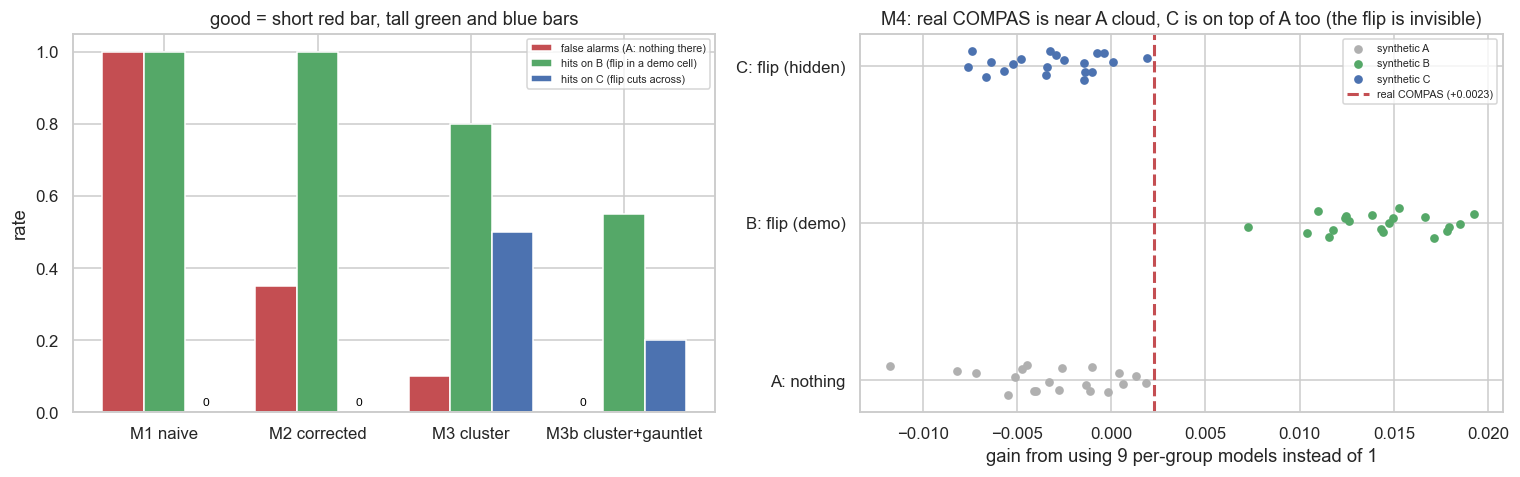

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

names = list(flip_methods)
x = np.arange(len(names)); w = 0.27
axes[0].bar(x - w, [false_alarm[m] for m in names], w, label="false alarms (A: nothing there)", color="#C44E52")
axes[0].bar(x,     [hit[m][0] for m in names],      w, label="hits on B (flip in a demo cell)",  color="#55A868")
axes[0].bar(x + w, [hit[m][1] for m in names],      w, label="hits on C (flip cuts across)",     color="#4C72B0")
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("rate")
axes[0].set_title("good = short red bar, tall green and blue bars")
axes[0].legend(fontsize=7)
for i, m in enumerate(names):                      # label the zeros so they are not mistaken for missing
    for off, v in [(-w, false_alarm[m]), (0, hit[m][0]), (w, hit[m][1])]:
        if v == 0:
            axes[0].text(i + off, 0.02, "0", ha="center", fontsize=8, color="black")

real_gain = M4_gain(y_real)
for i, s in enumerate(SYNTH):
    v = np.array(res_gain[s])
    col = {"A": "#B0B0B0", "B": "#55A868", "C": "#4C72B0"}[s]
    axes[1].scatter(v, np.full(len(v), i) + np.random.uniform(-.1, .1, len(v)), color=col, s=22,
                    label=f"synthetic {s}")
axes[1].axvline(real_gain, color="#C44E52", lw=2, ls="--", label=f"real COMPAS ({real_gain:+.4f})")
axes[1].set_yticks([0, 1, 2]); axes[1].set_yticklabels(["A: nothing", "B: flip (demo)", "C: flip (hidden)"])
axes[1].set_xlabel("gain from using 9 per-group models instead of 1")
axes[1].set_title("M4: real COMPAS is near A cloud, C is on top of A too (the flip is invisible)")
axes[1].legend(fontsize=7)

plt.tight_layout(); plt.show()

## Part 5: Using real COMPAS

In [21]:
rng = np.random.default_rng(SEED)

print("real COMPAS")
print("=" * 78)
for m, fn in flip_methods.items():
    got = fn(y_real, rng)
    fa, (hb, hc) = false_alarm[m], hit[m]
    print(f"\n{m}")
    print(f"  says            : {got if got else 'no flips'}")
    print(f"  its track record: {fa:.0%} false alarms | {hb:.0%} hits on B | {hc:.0%} hits on C")
    if fa >= 0.5:
        print(f"  verdict: false alarms on {fa:.0%} of empty datasets")
    elif not got:
        print(f"  verdict: no flip found, by a method that can find one ({hb:.0%} on B). that is real")
        print(f"           evidence of demographic no flip.")
    else:
        print(f"  verdict: a flip found by a method with few false alarms")

za = np.array(res_gain["A"])
z = (real_gain - za.mean()) / za.std()
zb = (np.mean(res_gain["B"]) - za.mean()) / za.std()
print(f"\nM4 gain")
print(f"  real COMPAS: {real_gain:+.4f}   z = {z:+.1f} versus the no-flip world")
print(f"  for scale, a known real flip scores z = {zb:+.1f}")

real COMPAS

M1 naive
  says            : ['juv_fel_count', 'juv_misd_count', 'juv_other_count']
  its track record: 100% false alarms | 100% hits on B | 0% hits on C
  verdict: false alarms on 100% of empty datasets

M2 corrected
  says            : no flips
  its track record: 35% false alarms | 100% hits on B | 0% hits on C
  verdict: no flip found, by a method that can find one (100% on B). that is real
           evidence of demographic no flip.

M3 cluster
  says            : no flips
  its track record: 10% false alarms | 80% hits on B | 50% hits on C
  verdict: no flip found, by a method that can find one (80% on B). that is real
           evidence of demographic no flip.

M3b cluster+gauntlet
  says            : no flips
  its track record: 0% false alarms | 55% hits on B | 20% hits on C
  verdict: no flip found, by a method that can find one (55% on B). that is real
           evidence of demographic no flip.

M4 gain
  real COMPAS: +0.0023   z = +1.6 versus the no-flip worl

## Part 6: Per-group models

The comparison is one global model versus nine per-group models, using the same model class on both sides.

In [ ]:
def split_vs_global(y, kind, min_n=100, seed=SEED):
    mk = (lambda: make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=3000))) \
         if kind == "logistic" else make_xgb
    pg, pl = np.zeros(len(y)), np.zeros(len(y))
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=seed).split(Xv, y):
        gm = mk().fit(Xv[tr], y[tr]); pg[te] = gm.predict_proba(Xv[te])[:, 1]
        gtr, gte = groups.iloc[tr], groups.iloc[te]
        for g in pd.unique(gte):
            tem, trm = (gte == g).values, (gtr == g).values
            if trm.sum() < min_n or len(np.unique(y[tr][trm])) < 2:
                pl[np.array(te)[tem]] = pg[np.array(te)[tem]]; continue
            lm = mk().fit(Xv[tr][trm], y[tr][trm])
            pl[np.array(te)[tem]] = lm.predict_proba(Xv[te][tem])[:, 1]
    return log_loss(y, pg), log_loss(y, pl)


print("one global model vs nine per-group models (cross validated log loss)")
print("=" * 80)
print(f"{'model class':>12}  {'1 global':>10}  {'9 per-group':>13}  {'splitting helps?':>18}")
print("-" * 80)
for kind in ["logistic", "xgboost"]:
    g, l = split_vs_global(y_real, kind)
    print(f"{kind:>12}  {g:10.4f}  {l:13.4f}  {('yes, by %+.4f' % (g-l)) if l < g else ('NO, worse by %.4f' % (l-g)):>18}")

one global model vs nine per-group models (cross validated log loss)
 model class    1 global    9 per-group    splitting helps?
--------------------------------------------------------------------------------
    logistic      0.6075         0.6052     yes, by +0.0023


In [ ]:
# how much worse is the global model on each group than the best model for that group?

pg, pl = np.zeros(len(y_real)), np.zeros(len(y_real))
for tr, te in StratifiedKFold(5, shuffle=True, random_state=SEED).split(Xs, y_real):
    gm = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)).fit(Xs[tr], y_real[tr])
    pg[te] = gm.predict_proba(Xs[te])[:, 1]
    gtr, gte = groups.iloc[tr], groups.iloc[te]
    for g in pd.unique(gte):
        tem, trm = (gte == g).values, (gtr == g).values
        if trm.sum() < 100:
            pl[np.array(te)[tem]] = pg[np.array(te)[tem]]; continue
        lm = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)).fit(Xs[tr][trm], y_real[tr][trm])
        pl[np.array(te)[tem]] = lm.predict_proba(Xs[te][tem])[:, 1]

rows = []
for g in sorted(groups.unique()):
    m = (groups == g).values
    if m.sum() < 100: continue
    e_glob = ((pg[m] >= .5).astype(int) != y_real[m]).mean()
    e_loc  = ((pl[m] >= .5).astype(int) != y_real[m]).mean()
    rows.append({"group": g, "n": int(m.sum()),
                 "error_global": e_glob, "error_pergroup": e_loc,
                 "delta": e_loc - e_glob})   # negative = the group's own model helps it
rr = pd.DataFrame(rows).sort_values("delta")
print("per-group error: global model vs the group's own model (same CV folds)")
print(rr.round(3).to_string(index=False))
print()
print("mixed signs and small magnitudes: this is what structural-but-not-exploitable looks like")
print("at this partition. no group is being systematically failed by the global model.")

per-group error: global model vs the group's own model (same CV folds)
                             group    n  error_global  error_pergroup  delta
          Caucasian / Less than 25  347         0.346           0.323 -0.023
           Other / Greater than 45  197         0.249           0.239 -0.010
              Other / Less than 25  191         0.356           0.351 -0.005
       Caucasian / Greater than 45  628         0.248           0.245 -0.003
                   Other / 25 - 45  506         0.312           0.314  0.002
   African-American / Less than 25  809         0.337           0.340  0.002
               Caucasian / 25 - 45 1128         0.352           0.355  0.004
        African-American / 25 - 45 1898         0.303           0.311  0.008
African-American / Greater than 45  468         0.321           0.346  0.026

mixed signs and small magnitudes: this is what structural-but-not-exploitable looks like
at this partition. no group is being systematically failed by the glo